### Human in the Loop

In [173]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model = "qwen-2.5-32b")

result = llm.invoke("Hello")
result

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 30, 'total_tokens': 40, 'completion_time': 0.05, 'prompt_time': 0.003707071, 'queue_time': 0.234786926, 'total_time': 0.053707071}, 'model_name': 'qwen-2.5-32b', 'system_fingerprint': 'fp_35f92f8282', 'finish_reason': 'stop', 'logprobs': None}, id='run-c4c7aa12-47bc-4235-9916-50a8bc5495b8-0', usage_metadata={'input_tokens': 30, 'output_tokens': 10, 'total_tokens': 40})

In [174]:
def add(a:int,b:int)->int:
    """ 
    Add a and b

    Args:
        a: first integer
        b: second integer
    """
    return a+b

def multiply(a:int,b:int)->int:
    """ 
    Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a*b 

def divide(a:int,b:int)->int:
    """ 
    Divide a and b.
    Args:
        a: first int
        b: second int
    """
    return a/b

tools = [add,multiply,divide]
llm_with_tools = llm.bind_tools(tools)

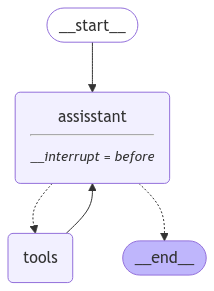

In [175]:
from IPython.display import Image,display 
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState,START,StateGraph
from langgraph.prebuilt import tools_condition,ToolNode

from langchain_core.messages import SystemMessage,HumanMessage,AIMessage

# System message
sys_msg = SystemMessage(content = "You are a helpful assisstant tasked with performing arithmetic on set of inputs")

def assisstant(state:MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg]+state["messages"])]}

#Graph
builder = StateGraph(MessagesState)

#Node
builder.add_node("assisstant",assisstant)
builder.add_node("tools",ToolNode(tools))
builder.add_edge(START,"assisstant")

builder.add_conditional_edges(
    "assisstant",
    tools_condition
)
builder.add_edge("tools","assisstant")

memory = MemorySaver()

graph = builder.compile(interrupt_before=["assisstant"],checkpointer=memory)

#show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [176]:
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

thread = {"configurable":{"thread_id":1}}


In [177]:
for event in graph.stream(initial_input,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [178]:
state = graph.get_state(thread)
state.next

('assisstant',)

In [179]:
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='3e750687-e3b1-462f-a64a-c42af383d6ec')]}, next=('assisstant',), config={'configurable': {'thread_id': 1, 'checkpoint_ns': '', 'checkpoint_id': '1eff4180-c1b6-62b7-8000-558a58c8eb45'}}, metadata={'source': 'loop', 'writes': None, 'thread_id': 1, 'step': 0, 'parents': {}}, created_at='2025-02-26T08:02:39.128836+00:00', parent_config={'configurable': {'thread_id': 1, 'checkpoint_ns': '', 'checkpoint_id': '1eff4180-c1ad-6304-bfff-5fb68882c076'}}, tasks=(PregelTask(id='670a82ac-0643-ca7f-38ad-f8861770c91c', name='assisstant', path=('__pregel_pull', 'assisstant'), error=None, interrupts=(), state=None, result=None),))

In [180]:
for event in graph.stream(None,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_hkfe)
 Call ID: call_hkfe
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


### Edit the human feedback

In [181]:
initial_input = {"messages":HumanMessage(content="multiply 2 and 3")}
thread2 = {"configurable":{"thread_id":2}}

for event in graph.stream(initial_input,thread2,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

multiply 2 and 3


In [182]:
graph.update_state(thread2,{"messages": [HumanMessage(content = "No, Actually multiply 15 and 5!")]})

{'configurable': {'thread_id': 2,
  'checkpoint_ns': '',
  'checkpoint_id': '1eff4180-ca0d-67c7-8001-70cc28247c1c'}}

In [183]:
new_state = graph.get_state(thread2).values
for m in new_state["messages"]:
    m.pretty_print()

================================ Human Message =================================

multiply 2 and 3
================================ Human Message =================================

No, Actually multiply 15 and 5!


In [184]:
for event in graph.stream(None,thread2,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

No, Actually multiply 15 and 5!
================================== Ai Message ==================================
Tool Calls:
  multiply (call_jhck)
 Call ID: call_jhck
  Args:
    a: 15
    b: 5
================================= Tool Message =================================
Name: multiply

75


In [185]:
for event in graph.stream(None,thread2,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

75
================================== Ai Message ==================================

The product of 15 and 5 is 75.


### Wait for an user input

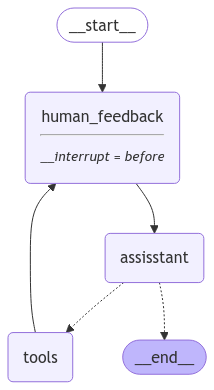

In [186]:

# System message
sys_msg = SystemMessage(content = "You are a helpful assisstant tasked with performing arithmetic on set of inputs")

def human_feedback(state:MessagesState):
    user_input = input("Tell me how you want to update the state: ")
    state["messages"] = user_input 
    return state


def assisstant(state:MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg]+state["messages"])]}

#Graph
builder = StateGraph(MessagesState)

#Node
builder.add_node("assisstant",assisstant)
builder.add_node("tools",ToolNode(tools))
builder.add_node("human_feedback",human_feedback)
builder.add_edge(START,"human_feedback")
builder.add_edge("human_feedback","assisstant")
builder.add_conditional_edges(
    "assisstant",
    tools_condition
)
builder.add_edge("tools","human_feedback")

memory = MemorySaver()

graph = builder.compile(interrupt_before=["human_feedback"],checkpointer=memory)

#show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [187]:
# Fixed variable name to avoid conflict with built-in input()
input_data = {"messages": [HumanMessage(content="Multiply 2 and 3")]}

thread3 = {"configurable": {"thread_id": 3}}

for event in graph.stream(input_data, thread3, stream_mode="values"):
    event["messages"][-1].pretty_print()



graph.update_state(thread3,human_feedback({"messages":""}), as_node="human_feedback")

for event in graph.stream(None, thread3, stream_mode="values"):
    event["messages"][-1].pretty_print()


================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

divide 6 by 3
================================== Ai Message ==================================
Tool Calls:
  divide (call_kn8a)
 Call ID: call_kn8a
  Args:
    a: 6
    b: 3
================================= Tool Message =================================
Name: divide

2.0


In [188]:
graph.get_state(thread3).next

('human_feedback',)

In [189]:
for event in graph.stream(None, thread3, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: divide

2.0
================================ Human Message =================================

divide 5 by 2
================================== Ai Message ==================================
Tool Calls:
  divide (call_eg9c)
 Call ID: call_eg9c
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: divide

2.5


In [191]:
state = graph.get_state(thread3)
state.next

('human_feedback',)